# Named Entity Recognition (NER) Pipeline
# Code đầy đủ và data tại: https://github.com/duyhoang17930/Named-Entity-Recognition
## Complete Pipeline: Crawl → Preprocess → label → Encode →  Train → Evaluate → Predict

This notebook contains all steps for building an NER system:
1. **Day1 - Crawl**: Data collection from Google News
2. **Day2 - Preprocess**: Text cleaning and preprocessing
3. **Day3 - Encode**: NER labeling with spaCy
5. **Day4 - Relabeling**: Apply custom entity mappings for improved accuracy
6. **Day5 - Train**: Model training with DistilBERT
7. **Day6 - Results**: Evaluation, visualization, and prediction

# Step 2: Text Preprocessing (Day2)

Preprocessing steps:
- Remove noise (emails, special patterns)
- Tokenization
- Remove stopwords
- Lemmatization

In [7]:
import pandas as pd
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

class TextPreprocessor:
    """Text preprocessing class for cleaning news data"""

    def __init__(self):
        noise_patterns = [
            r'summary.*?-',
            r'opens new tab',
            r'reuters inside track.*',
            r'reporting by.*',
            r'editing by.*',
            r'our standards.*',
            r'can be reached at.*'
        ]
        self.noise_regex = [re.compile(p, re.IGNORECASE) for p in noise_patterns]

    def clean_text(self, text):
        """Clean and preprocess text"""
        if pd.isna(text):
            return ""
        
        # Remove noise patterns
        for pattern in self.noise_regex:
            text = pattern.sub('', text)
        # Remove emails
        text = re.sub(r'\S+@\S+', '', text)
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()

        # Tokenize
        tokens = nltk.word_tokenize(text)
        
        # Remove stopwords and lemmatize
        tokens = [
            lemmatizer.lemmatize(w)
            for w in tokens
            if w not in stop_words and len(w) > 2
        ]

        return " ".join(tokens)


class DataStats:
    """Statistics class for data analysis"""

    @staticmethod
    def raw_stats(df):
        print("\n" + "=" * 50)
        print("RAW DATA STATISTICS")
        print("=" * 50)
        print(f"Total sentences: {len(df)}")
        print(f"Unique titles: {df['Title'].nunique()}")
        print(f"Missing values: {df.isna().sum().sum()}")

    @staticmethod
    def clean_stats(df, column):
        lengths = df[column].str.split().apply(len)

        print("\n" + "=" * 50)
        print("CLEAN DATA STATISTICS")
        print("=" * 50)
        print(f"Clean samples: {len(df)}")
        print(f"Avg sentence length: {round(lengths.mean(), 2)}")
        print(f"Max length: {lengths.max()}")
        print(f"Min length: {lengths.min()}")

        all_words = " ".join(df[column]).split()
        common = Counter(all_words).most_common(10)

        print("\nTop 10 frequent words:")
        for word, count in common:
            print(f"  {word}: {count}")

        return lengths.mean(), common

In [8]:
# Run preprocessing
print("Loading data...")
df = pd.read_csv("Day1_Crawl/ket_qua_sentence.csv")

raw_count = len(df)
DataStats.raw_stats(df)

processor = TextPreprocessor()

print("\nCleaning text...")
df["clean_sentence"] = df["Sentence"].apply(processor.clean_text)

# Filter: at least 6 words
df = df[df["clean_sentence"].str.split().str.len() >= 6]

# Remove duplicates
df.drop_duplicates(subset=["clean_sentence"], inplace=True)

clean_count = len(df)

print(f"\nRemoved sentences: {raw_count - clean_count}")

avg_len, common_words = DataStats.clean_stats(df, "clean_sentence")

# Save cleaned data
df.to_csv("clean_news.csv", index=False)

print("\nDONE! Saved clean data to: clean_news.csv")

Loading data...

RAW DATA STATISTICS
Total sentences: 3680
Unique titles: 149
Missing values: 0

Cleaning text...

Removed sentences: 513

CLEAN DATA STATISTICS
Clean samples: 3167
Avg sentence length: 15.97
Max length: 224
Min length: 6

Top 10 frequent words:
  said: 744
  The: 663
  Epstein: 323
  Trump: 284
  U.S.: 261
  year: 209
  would: 199
  last: 190
  also: 175
  Reuters: 163

DONE! Saved clean data to: clean_news.csv


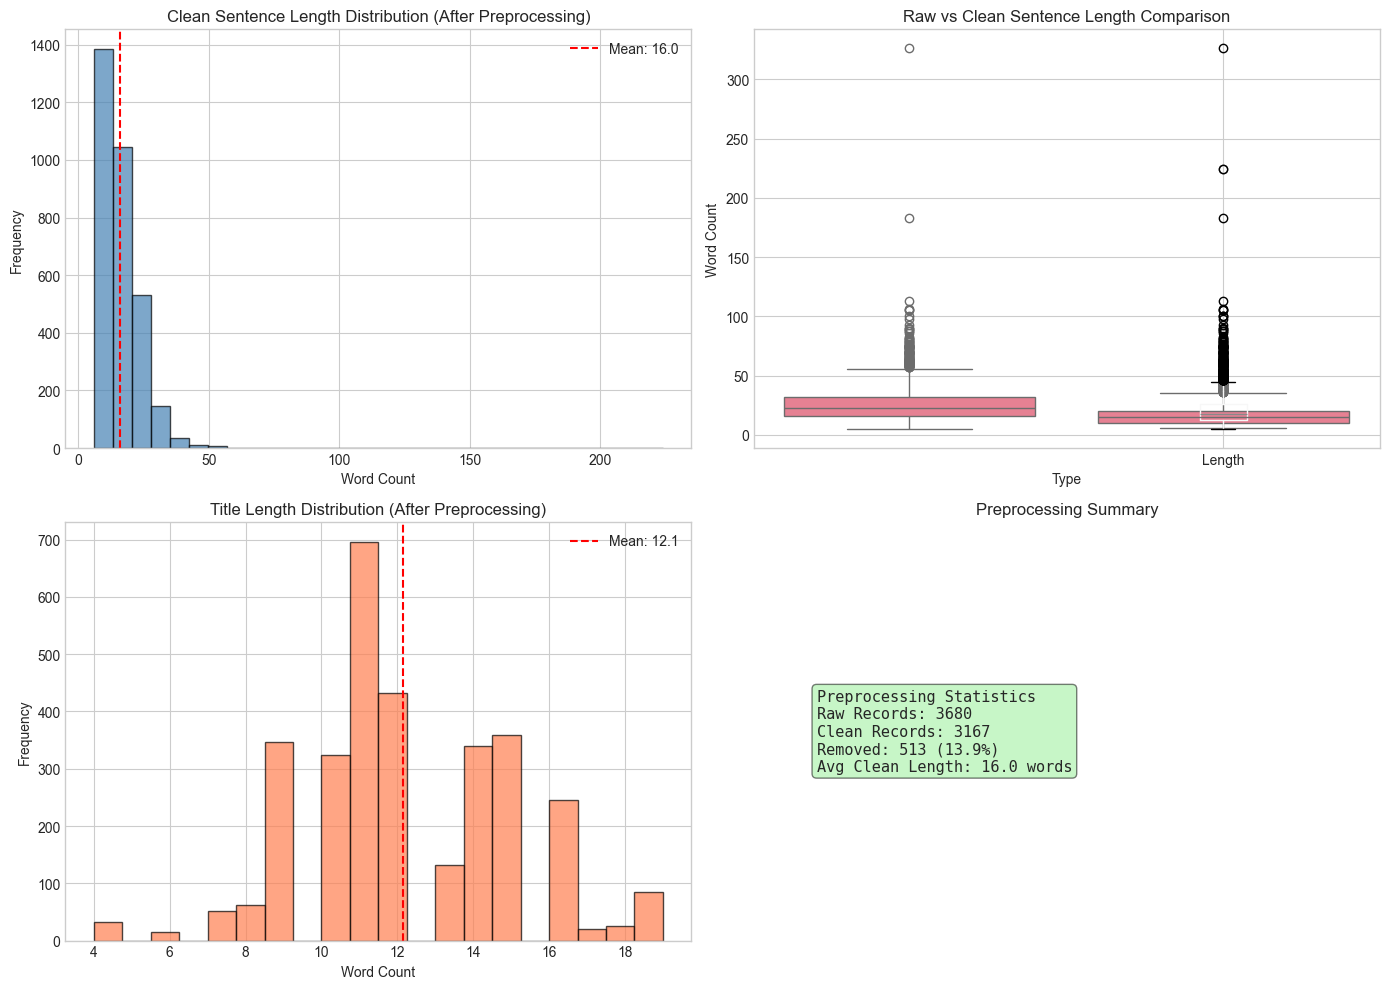

Saved: charts/after_preprocessing_analysis.png


In [39]:
# Data Visualization: After Preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load preprocessed data
df_clean = pd.read_csv('clean_news.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Clean sentence length distribution
df_clean['clean_length'] = df_clean['clean_sentence'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
axes[0, 0].hist(df_clean['clean_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_clean['clean_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_clean['clean_length'].mean(), 1)))
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Clean Sentence Length Distribution (After Preprocessing)')
axes[0, 0].legend()

# 2. Sentence length comparison (before vs after)
df_raw = pd.read_csv('Day1_Crawl/ket_qua_sentence.csv')
df_raw['raw_length'] = df_raw['Sentence'].apply(lambda x: len(str(x).split()))
comparison_data = pd.concat([
    pd.DataFrame({'Length': df_raw['raw_length'], 'Type': 'Raw'}),
    pd.DataFrame({'Length': df_clean['clean_length'], 'Type': 'Clean'})
])

sns.boxplot(data=comparison_data, x='Type', y='Length', ax=axes[0, 1])
axes[0, 1].set_title('Raw vs Clean Sentence Length Comparison')
comparison_data.boxplot(ax=axes[0, 1])
axes[0, 1].set_ylabel('Word Count')
axes[0, 1].set_title('Raw vs Clean Sentence Length Comparison')

# 3. Title length in cleaned data
df_clean['title_length'] = df_clean['Title'].apply(lambda x: len(str(x).split()))
axes[1, 0].hist(df_clean['title_length'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].axvline(df_clean['title_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_clean['title_length'].mean(), 1)))
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Title Length Distribution (After Preprocessing)')
axes[1, 0].legend()

# 4. Preprocessing stats
raw_count = len(df_raw)
clean_count = len(df_clean)
removed = raw_count - clean_count
stats_text = (
    "Preprocessing Statistics\n"
    "Raw Records: " + str(raw_count) + "\n"
    "Clean Records: " + str(clean_count) + "\n"
    "Removed: " + str(removed) + " (" + str(round(removed/raw_count*100, 1)) + "%)\n"
    "Avg Clean Length: " + str(round(df_clean['clean_length'].mean(), 1)) + " words"
)
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1, 1].axis('off')
axes[1, 1].set_title('Preprocessing Summary')

plt.tight_layout()
plt.savefig('charts/after_preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/after_preprocessing_analysis.png')

---